## Section 1: Structure & sanity checks

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path(r'C:\Personal\data')


In [8]:
df = pd.read_csv(DATA_DIR / 'incident_events.csv')
print('Shape:', df.shape)
df.head()

Shape: (69, 10)


,node,incidentDate,incidentDate2,description,category,beforeHours,afterHours,collectStart,collectEnd,windowTotalHours
0,node_38972d8a27de,11 Jul 2025,NaN,gpu problem,gpu error/problem,24,2,2025-07-10 00:00:00,2025-07-11 02:00:00,26
1,node_473ac80c8602,19 Jan 2025,NaN,gpu problem,gpu error/problem,24,2,2025-01-18 00:00:00,2025-01-19 02:00:00,26
2,node_2cad8ec37e1d,28 Jan 2025,NaN,gpu error,gpu error/problem,24,2,2025-01-27 00:00:00,2025-01-28 02:00:00,26
3,node_15e3440a80d0,07 Jan 2025,NaN,gpu ecc problem,gpu ecc,24,2,2025-01-06 00:00:00,2025-01-07 02:00:00,26
4,node_15e3440a80d0,14 Jan 2025,NaN,gpu ecc problem,gpu ecc,24,2,2025-01-13 00:00:00,2025-01-14 02:00:00,26


In [ ]:
# how many unique categories total
print('Unique categories:', df['category'].nunique())

Unique categories: 8


In [ ]:
# Data Types

node                    str
incidentDate            str
incidentDate2       float64
description             str
category                str
beforeHours           int64
afterHours            int64
collectStart            str
collectEnd              str
windowTotalHours      int64
dtype: object

In [16]:
df.isna().sum()

node                 0
incidentDate         0
incidentDate2       69
description          0
category             0
beforeHours          0
afterHours           0
collectStart         0
collectEnd           0
windowTotalHours     0
dtype: int64

In [18]:
df = df.drop(columns=["incidentDate2"])

In [19]:
df.head()

,node,incidentDate,description,category,beforeHours,afterHours,collectStart,collectEnd,windowTotalHours
0,node_38972d8a27de,11 Jul 2025,gpu problem,gpu error/problem,24,2,2025-07-10 00:00:00,2025-07-11 02:00:00,26
1,node_473ac80c8602,19 Jan 2025,gpu problem,gpu error/problem,24,2,2025-01-18 00:00:00,2025-01-19 02:00:00,26
2,node_2cad8ec37e1d,28 Jan 2025,gpu error,gpu error/problem,24,2,2025-01-27 00:00:00,2025-01-28 02:00:00,26
3,node_15e3440a80d0,07 Jan 2025,gpu ecc problem,gpu ecc,24,2,2025-01-06 00:00:00,2025-01-07 02:00:00,26
4,node_15e3440a80d0,14 Jan 2025,gpu ecc problem,gpu ecc,24,2,2025-01-13 00:00:00,2025-01-14 02:00:00,26


In [20]:
# convert date/time columns properly
df['incidentDate'] = pd.to_datetime(df['incidentDate'], format='%d %b %Y')
df['collectStart'] = pd.to_datetime(df['collectStart'])
df['collectEnd'] = pd.to_datetime(df['collectEnd'])

df[['node', 'incidentDate', 'collectStart', 'collectEnd']].head()

,node,incidentDate,collectStart,collectEnd
0,node_38972d8a27de,2025-07-11,2025-07-10,2025-07-11 02:00:00
1,node_473ac80c8602,2025-01-19,2025-01-18,2025-01-19 02:00:00
2,node_2cad8ec37e1d,2025-01-28,2025-01-27,2025-01-28 02:00:00
3,node_15e3440a80d0,2025-01-07,2025-01-06,2025-01-07 02:00:00
4,node_15e3440a80d0,2025-01-14,2025-01-13,2025-01-14 02:00:00


In [28]:
# confirm beforeHours / afterHours / windowTotalHours are constant
df[['beforeHours', 'afterHours', 'windowTotalHours']].drop_duplicates()

,beforeHours,afterHours,windowTotalHours
0,24,2,26


In [29]:
# confirm collectStart/collectEnd are just arithmetic derivations of incidentDate
check = df.copy()
check['expected_start'] = check['incidentDate'] - pd.to_timedelta(check['beforeHours'], unit='h')
check['expected_end'] = check['incidentDate'] + pd.to_timedelta(check['afterHours'], unit='h')

check['start_matches'] = check['expected_start'] == check['collectStart']
check['end_matches'] = check['expected_end'] == check['collectEnd']

print('All start times match formula:', check['start_matches'].all())
print('All end times match formula:', check['end_matches'].all())

All start times match formula: True
All end times match formula: True


## Section 2: Nodel-level Distribution

In [24]:
print('Unique nodes:', df['node'].nunique())
print('Total incidents:', len(df))

Unique nodes: 26
Total incidents: 69


In [25]:
incidents_per_node = df['node'].value_counts()
incidents_per_node

node
node_ada68b80182e    15
node_95799a17101c    11
node_6a5ebc855306     5
node_2348d3608e24     5
node_b1b91a387252     3
node_039ab2df8a6a     3
node_dfc60a085f94     3
node_1a061e79b6d1     3
node_15e3440a80d0     2
node_82d89aec502a     2
node_484a8d060485     2
node_38972d8a27de     1
node_473ac80c8602     1
node_2cad8ec37e1d     1
node_0876e5fac0c8     1
node_2b08d249c0ba     1
node_df3724dfcace     1
node_62a6cb9d8856     1
node_d4119f476626     1
node_eb787fe5e4fa     1
node_d66992a09544     1
node_c1c418ff5f95     1
node_a4bc1d905d62     1
node_b33671ad48fb     1
node_39a26f4a5528     1
node_d603d0ec5d69     1
Name: count, dtype: int64

In [26]:
# how many nodes have only 1 incident vs multiple
single_incident_nodes = (incidents_per_node == 1).sum()
multi_incident_nodes = (incidents_per_node > 1).sum()

print('Nodes with exactly 1 incident:', single_incident_nodes)
print('Nodes with multiple incidents:', multi_incident_nodes)

Nodes with exactly 1 incident: 15
Nodes with multiple incidents: 11


In [27]:
# the repeat offenders
incidents_per_node[incidents_per_node > 1]

node
node_ada68b80182e    15
node_95799a17101c    11
node_6a5ebc855306     5
node_2348d3608e24     5
node_b1b91a387252     3
node_039ab2df8a6a     3
node_dfc60a085f94     3
node_1a061e79b6d1     3
node_15e3440a80d0     2
node_82d89aec502a     2
node_484a8d060485     2
Name: count, dtype: int64

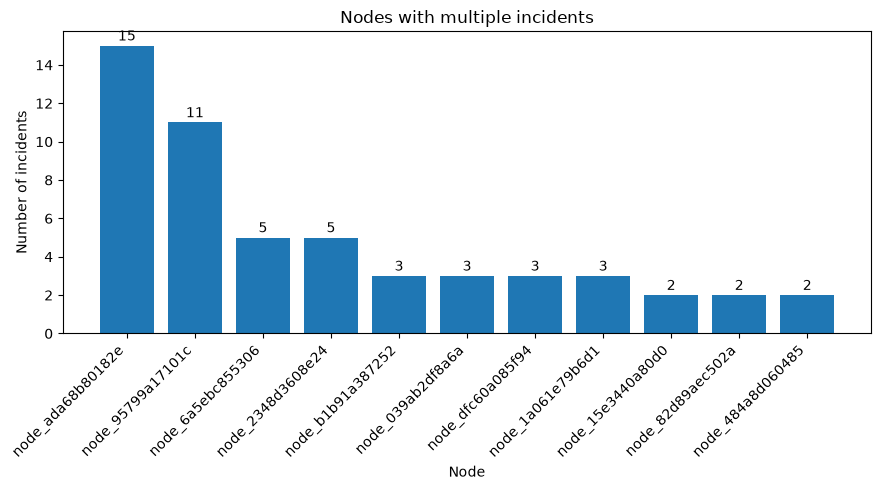

In [48]:
repeat_nodes = incidents_per_node[incidents_per_node > 1]

plt.figure(figsize=(9, 5))
bars = plt.bar(repeat_nodes.index, repeat_nodes.values)

# add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, int(height),
              ha='center', va='bottom')

plt.xlabel('Node')
plt.ylabel('Number of incidents')
plt.title('Nodes with multiple incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 3: Category / description analysis

In [41]:
# full category value counts - is this a clean small set usable as a label?
print('Incidents per category:', df['category'].value_counts())
# how many unique categories total
print('\nUnique categories:', df['category'].nunique())

Incidents per category: category
gpu error/problem    31
gpu fell off bus     24
gpu unknown           5
gpu lost              3
gpu ecc               2
gpu failed            2
gpu timeout           1
gpu handle error      1
Name: count, dtype: int64

Unique categories: 8


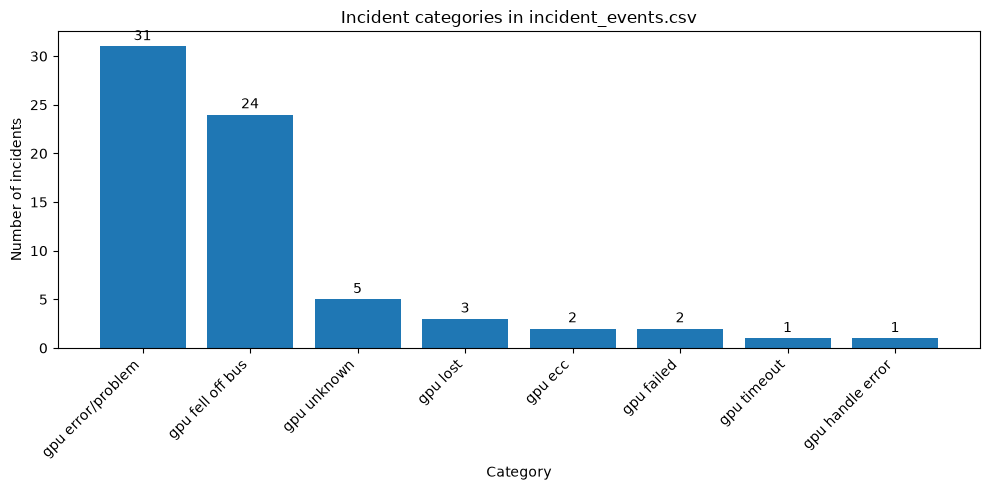

In [49]:
category_counts = df['category'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(category_counts.index, category_counts.values)

# add data labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.3, int(height),
              ha='center', va='bottom')

plt.xlabel('Category')
plt.ylabel('Number of incidents')
plt.title('Incident categories in incident_events.csv')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [50]:
# description -> category mapping: how much free-text variation collapses into each category
for cat, descs in df.groupby('category')['description'].unique().items():
    print(f'{cat}:')
    for d in descs:
        print(f'   - {d}')
    print()

gpu ecc:
   - gpu ecc problem

gpu error/problem:
   - gpu problem
   - gpu error
   - gpus uncooperative
   - gpus error

gpu failed:
   - gpus failed

gpu fell off bus:
   - gpu fell off bus
   - gpus fell off bus
   - gpus fell of bus

gpu handle error:
   - unable to determine gpu handle

gpu lost:
   - lost gpu

gpu timeout:
   - gpu timeout

gpu unknown:
   - gpus unknown error



In [51]:
# flag categories that look ambiguous/low-confidence as labels
ambiguous_keywords = ['unknown', 'uncooperative', 'unable to determine']
df['looks_ambiguous'] = df['description'].str.lower().str.contains('|'.join(ambiguous_keywords))

print('Ambiguous-sounding incidents:', df['looks_ambiguous'].sum())
df[df['looks_ambiguous']][['node', 'incidentDate', 'description', 'category']]

Ambiguous-sounding incidents: 7


,node,incidentDate,description,category
26,node_95799a17101c,2025-10-02,gpus unknown error,gpu unknown
28,node_95799a17101c,2025-10-11,gpus uncooperative,gpu error/problem
30,node_95799a17101c,2026-02-10,gpus unknown error,gpu unknown
31,node_95799a17101c,2026-02-12,gpus unknown error,gpu unknown
39,node_ada68b80182e,2025-04-27,gpus unknown error,gpu unknown
46,node_ada68b80182e,2026-02-11,gpus unknown error,gpu unknown
62,node_1a061e79b6d1,2025-09-12,unable to determine gpu handle,gpu handle error


## Section 4: Temporal analysis

In [52]:
print('Earliest incident:', df['incidentDate'].min())
print('Latest incident:', df['incidentDate'].max())
print('Total span (days):', (df['incidentDate'].max() - df['incidentDate'].min()).days)

Earliest incident: 2025-01-07 00:00:00
Latest incident: 2026-02-12 00:00:00
Total span (days): 401


In [53]:
# incident counts per exact date - looking for same-day clusters across multiple nodes
date_counts = df['incidentDate'].value_counts().sort_index()
date_counts

incidentDate
2025-01-07    1
2025-01-11    1
2025-01-12    1
2025-01-14    2
2025-01-15    1
2025-01-16    1
2025-01-19    1
2025-01-27    2
2025-01-28    1
2025-02-07    1
2025-02-10    3
2025-02-17    2
2025-03-14    2
2025-03-19    2
2025-03-21    6
2025-04-26    3
2025-04-27    1
2025-05-07    1
2025-05-20    2
2025-06-11    1
2025-06-12    2
2025-06-14    1
2025-06-24    1
2025-07-03    2
2025-07-04    1
2025-07-06    1
2025-07-11    1
2025-07-13    1
2025-09-12    4
2025-09-29    2
2025-10-02    1
2025-10-10    3
2025-10-11    1
2025-10-21    1
2025-10-22    1
2026-01-09    1
2026-01-10    1
2026-01-13    1
2026-01-19    3
2026-01-22    1
2026-02-06    1
2026-02-10    1
2026-02-11    1
2026-02-12    1
Name: count, dtype: int64